1. Read and Display the Image

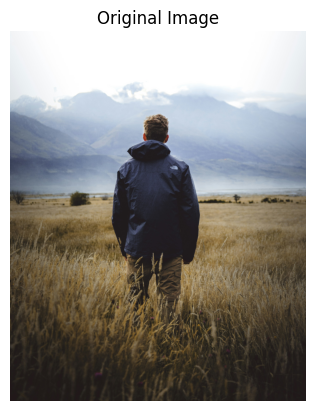

In [ ]:
from PIL import Image
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt

# Load image from internet
url = "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d"
image = Image.open(BytesIO(requests.get(url).content))

# Display image
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()

2. Display Top-Left 100×100 Pixels

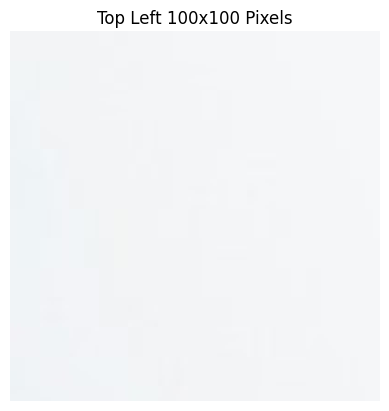

In [ ]:
# Convert to numpy array
image_array = np.array(image)

# Extract top-left 100x100
top_left = image_array[0:100, 0:100]

# Display
plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis('off')
plt.show()

3. Show R, G, B Channels (Using NumPy)

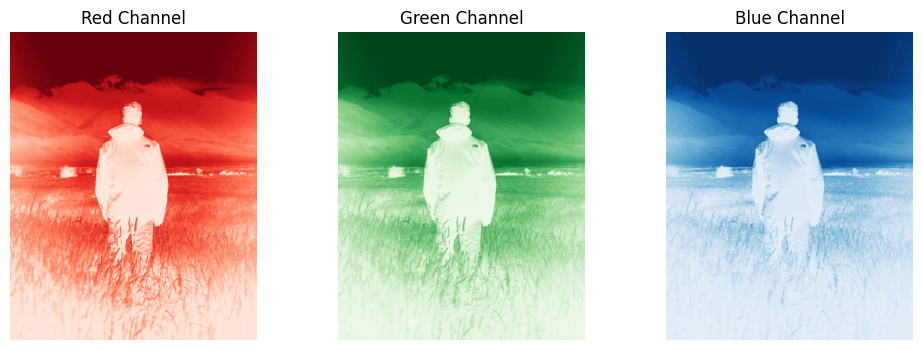

In [ ]:
# Separate channels
R = image_array[:, :, 0]
G = image_array[:, :, 1]
B = image_array[:, :, 2]

# Display each channel
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis('off')

plt.show()

4. Modify Top 100×100 Pixels to 210

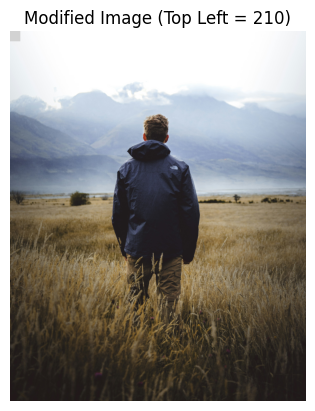

In [ ]:
# Copy image array (important!)
modified = image_array.copy()

# Set top-left 100x100 pixels to 210
modified[0:100, 0:100] = 210

# Display modified image
plt.imshow(modified)
plt.title("Modified Image (Top Left = 210)")
plt.axis('off')
plt.show()

2.2 Exercise - 2:
Complete all the Task.
1. Load and display a grayscale image.

• Load a grayscale image using the Pillow library.

• Display the grayscale image using matplotlib.

2. Extract and display the middle section of the image (150 pixels).

• Extract a 150 pixel section from the center of the image using NumPy array slicing.

• Display this cropped image using matplotlib.

3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).

• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values above 100 to 255 (creating a binary image).

• Display the resulting binary image.

4. Rotate the image 90 degrees clockwise and display the result.

• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating the image array.

• Display the rotated image using matplotlib.

5. Convert the grayscale image to an RGB image.

• Convert the grayscale image into an RGB image where the grayscale values are replicated across all three channels (R, G, and B).

• Display the converted RGB image using matplotlib.

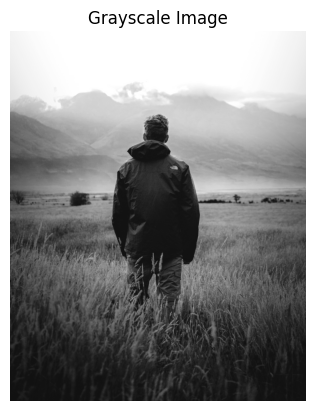

In [ ]:
from PIL import Image
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt

# Load image and convert to grayscale
url = "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d"
image = Image.open(BytesIO(requests.get(url).content)).convert('L')

# Display grayscale image
plt.imshow(image, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

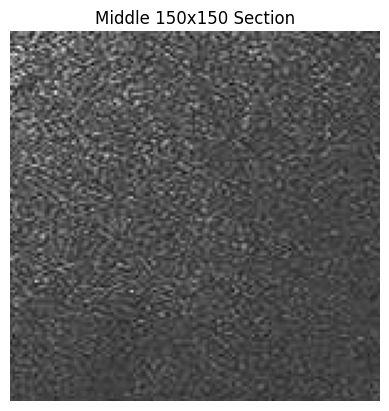

In [ ]:
# Convert to numpy array
image_array = np.array(image)

# Get center
h, w = image_array.shape
center_h, center_w = h // 2, w // 2

# Extract 150x150 region
middle = image_array[center_h-75:center_h+75, center_w-75:center_w+75]

# Display
plt.imshow(middle, cmap='gray')
plt.title("Middle 150x150 Section")
plt.axis('off')
plt.show()

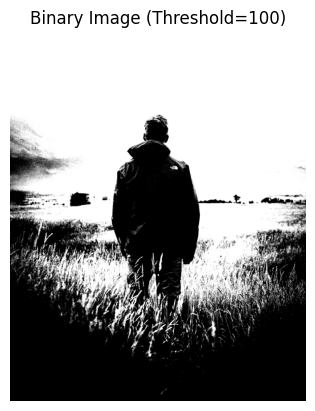

In [ ]:
# Apply threshold
binary = image_array.copy()
binary[binary < 100] = 0
binary[binary >= 100] = 255

# Display
plt.imshow(binary, cmap='gray')
plt.title("Binary Image (Threshold=100)")
plt.axis('off')
plt.show()

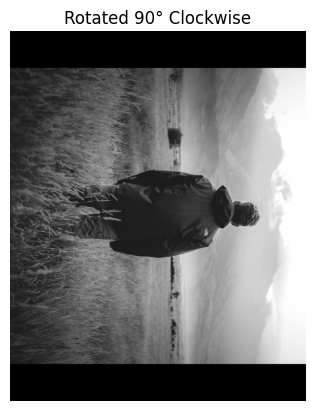

In [ ]:
rotated = image.rotate(-90)  # clockwise

plt.imshow(rotated, cmap='gray')
plt.title("Rotated 90° Clockwise")
plt.axis('off')
plt.show()

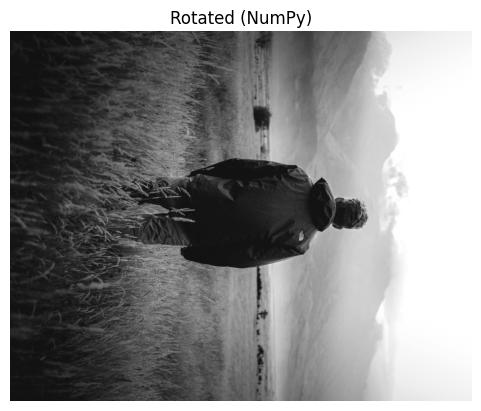

In [ ]:
rotated_np = np.rot90(image_array, k=-1)

plt.imshow(rotated_np, cmap='gray')
plt.title("Rotated (NumPy)")
plt.axis('off')
plt.show()

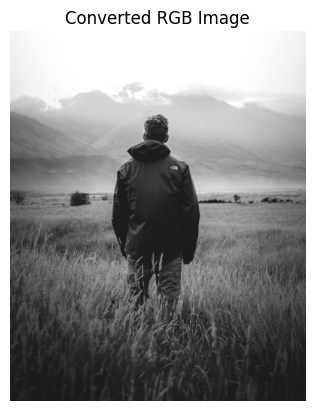

In [ ]:
# Stack grayscale into 3 channels
rgb_image = np.stack((image_array,)*3, axis=-1)

# Display
plt.imshow(rgb_image)
plt.title("Converted RGB Image")
plt.axis('off')
plt.show()

3 Image Compression and Decompression using PCA.
In this exercise, build a PCA from scratch using explained variance method for image compression task.
You are expected to compute the necessary matrices from the scratch. Dataset: Use image of your
choice.

1. Load and Prepare Data:

• Fetch an image of you choice.{If colour convert to grayscale}

• Center the dataset - Standaridze the Data.

• Calculate the covaraince matrix of the Standaridze data.

2. Eigen Decomposition and Identifying Principal Components:

• Compute Eigen Values and Eigen Vectors.

• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to the highest eigenvalues.

• Identify the Principal Components with the help of cumulative Sum plot.

3. Reconstruction and Experiment:

• Reconstruction: Transform the original data by multiplying it with the selected eigenvectors(PCs) to obtain a lower-dimensional representation.

• Experiments: Pick Four different combination of principal components with various explained variance value and compare the result.

• Display the Results and Evaluate.

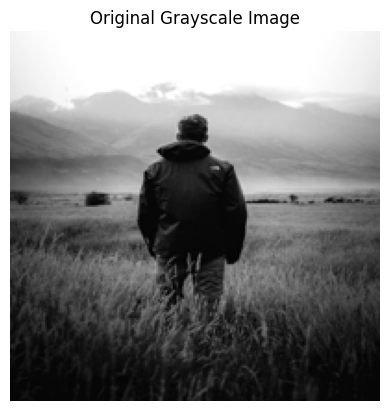

In [1]:
from PIL import Image
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt

# Load image
url = "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d"
img = Image.open(BytesIO(requests.get(url).content))

# Convert to grayscale
img = img.convert('L')

# Resize (smaller size for easier PCA computation)
img = img.resize((200,200))

# Display original image
plt.imshow(img, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')
plt.show()

# Convert to numpy array
X = np.array(img, dtype=float)

In [2]:
# Compute mean of each column
mean = np.mean(X, axis=0)

# Center the data
X_centered = X - mean


In [3]:
cov_matrix = np.cov(X_centered, rowvar=False)

print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (200, 200)


In [4]:
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

In [5]:
sorted_index = np.argsort(eigen_values)[::-1]

sorted_eigenvalues = eigen_values[sorted_index]
sorted_eigenvectors = eigen_vectors[:, sorted_index]

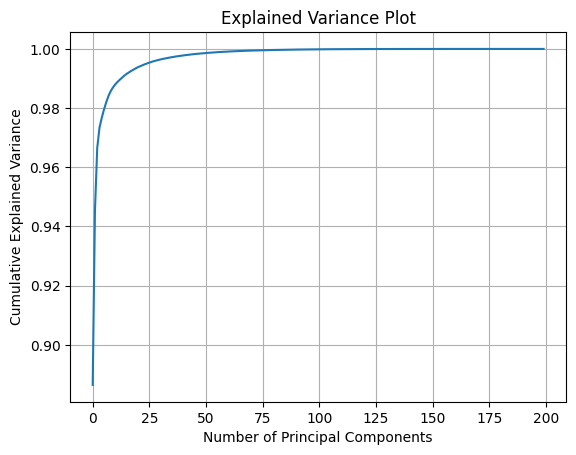

In [6]:
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.grid()
plt.show()

In [7]:
def reconstruct_image(k):

    # Select top k eigenvectors
    eigenvector_subset = sorted_eigenvectors[:, 0:k]

    # Transform to lower dimension
    X_reduced = np.dot(X_centered, eigenvector_subset)

    # Reconstruct image
    X_reconstructed = np.dot(X_reduced, eigenvector_subset.T) + mean

    return X_reconstructed

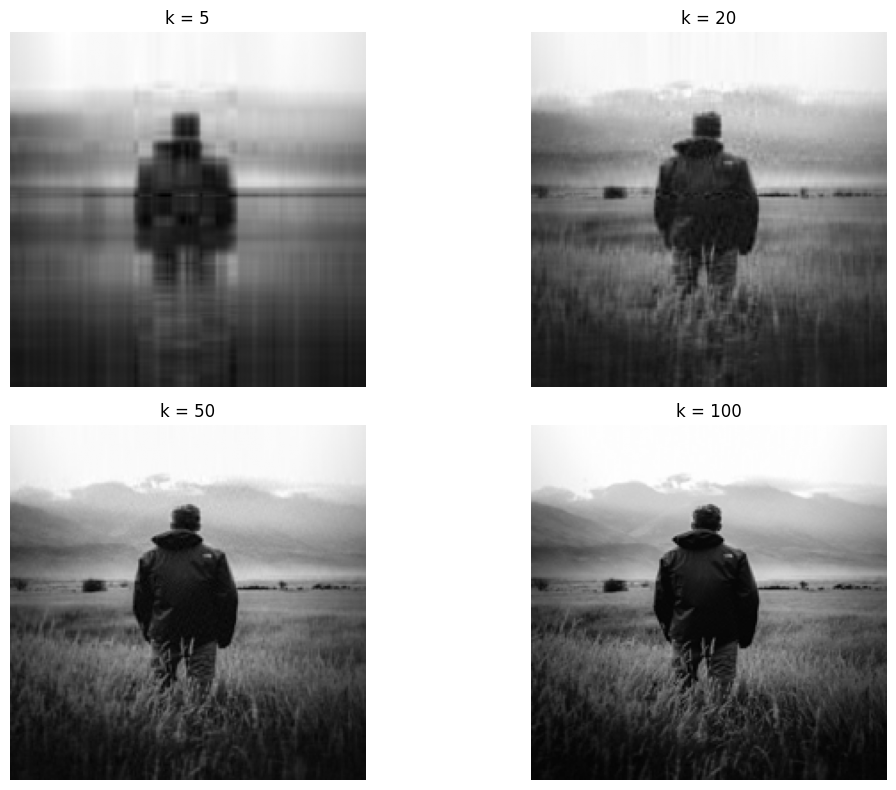

In [8]:
k_values = [5, 20, 50, 100]

plt.figure(figsize=(12,8))

for i,k in enumerate(k_values):

    reconstructed = reconstruct_image(k)

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"k = {k}")
    plt.axis('off')

plt.tight_layout()
plt.show()